# Import Libraries

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Import Dataset

In [2]:
RAW_PATH = "../data/master_ml_raw.xlsx"
df = pd.read_excel(RAW_PATH)
df.columns = ['density', 'cutting_speed', 'feed_rate', 'depth', 'cutting_force', 'axial_force']

# Analysis

## General Check

### Shape & Dtypes

In [3]:
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nColumn names:\n", df.columns.tolist())
df

Shape: (283140, 6)

Dtypes:
 density            int64
cutting_speed      int64
feed_rate          int64
depth            float64
cutting_force    float64
axial_force      float64
dtype: object

Column names:
 ['density', 'cutting_speed', 'feed_rate', 'depth', 'cutting_force', 'axial_force']


,density,cutting_speed,feed_rate,depth,cutting_force,axial_force
0,10,100,10,0.000,0.000,0.000
1,10,100,10,0.017,2.442,0.305
2,10,100,10,0.033,1.831,0.854
3,10,100,10,0.050,3.052,1.526
4,10,100,10,0.067,0.610,1.282
...,...,...,...,...,...,...
283135,25,63,20,32.833,551.148,86.609
283136,25,63,20,32.867,553.589,86.915
283137,25,63,20,32.900,548.096,87.403
283138,25,63,20,32.933,549.317,88.013


### Summary Stats

In [4]:
df.describe(include="all")

,density,cutting_speed,feed_rate,depth,cutting_force,axial_force
count,283140.000000,283140.000000,283140.000000,283140.000000,283140.000000,283140.000000
mean,16.818182,42.333333,13.846154,16.488462,167.996814,61.976601
std,5.339709,31.084170,3.997047,9.526294,215.499097,47.059216
min,10.000000,10.000000,10.000000,0.000000,-9.766000,0.000000
25%,10.000000,16.000000,10.000000,8.233000,32.349000,24.048000
50%,15.000000,32.500000,15.000000,16.491500,81.177000,45.471000
75%,20.000000,63.000000,15.000000,24.733000,222.778000,88.501000
max,25.000000,100.000000,20.000000,32.983000,1695.553000,332.153000


### Missing Values

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
print(pd.DataFrame({"missing": missing, "pct": missing_pct})
        .query("missing > 0")
        .sort_values("pct", ascending=False))

Empty DataFrame
Columns: [missing, pct]
Index: []


### Duplicates

In [6]:
print(f"\nDuplicate rows: {df.duplicated().sum()}")


Duplicate rows: 163


### Unique Values per Column

In [7]:
print("\nUnique values per column:")
print(df.nunique().sort_values())


Unique values per column:
feed_rate           3
density             4
cutting_speed       6
depth            2640
cutting_force    5735
axial_force      6734
dtype: int64


### Numeric Distribution

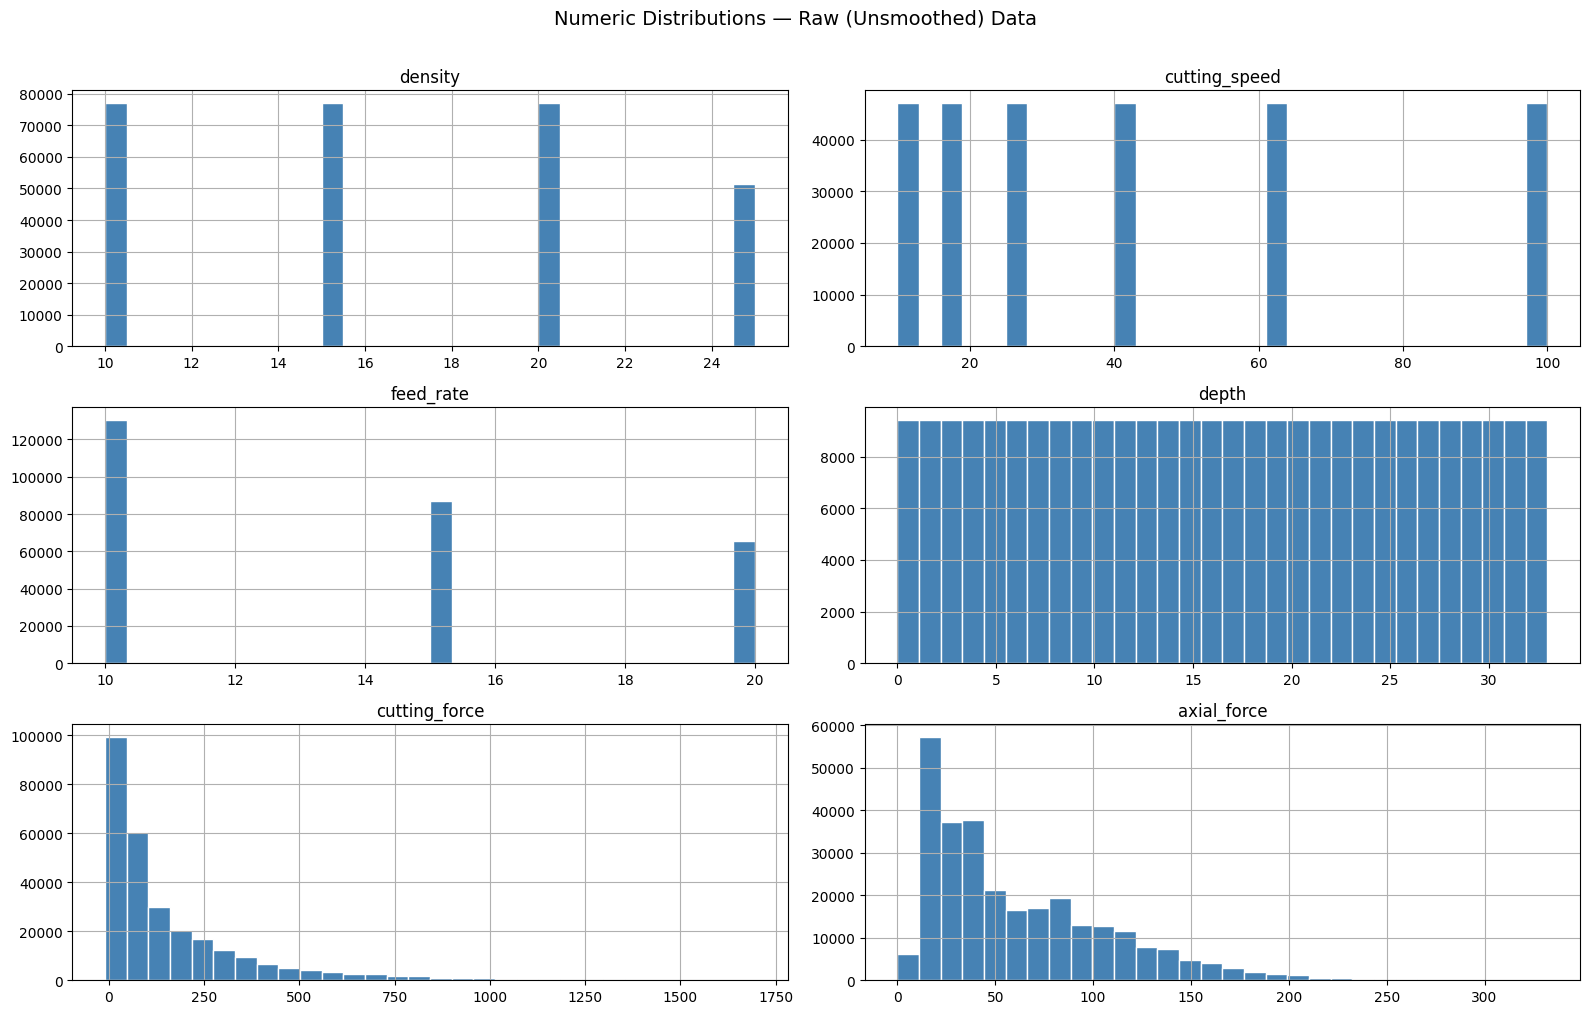

In [8]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()

df[num_cols].hist(figsize=(16, 10), bins=30, edgecolor="white", color="steelblue")
plt.suptitle("Numeric Distributions — Raw (Unsmoothed) Data", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Boxplots

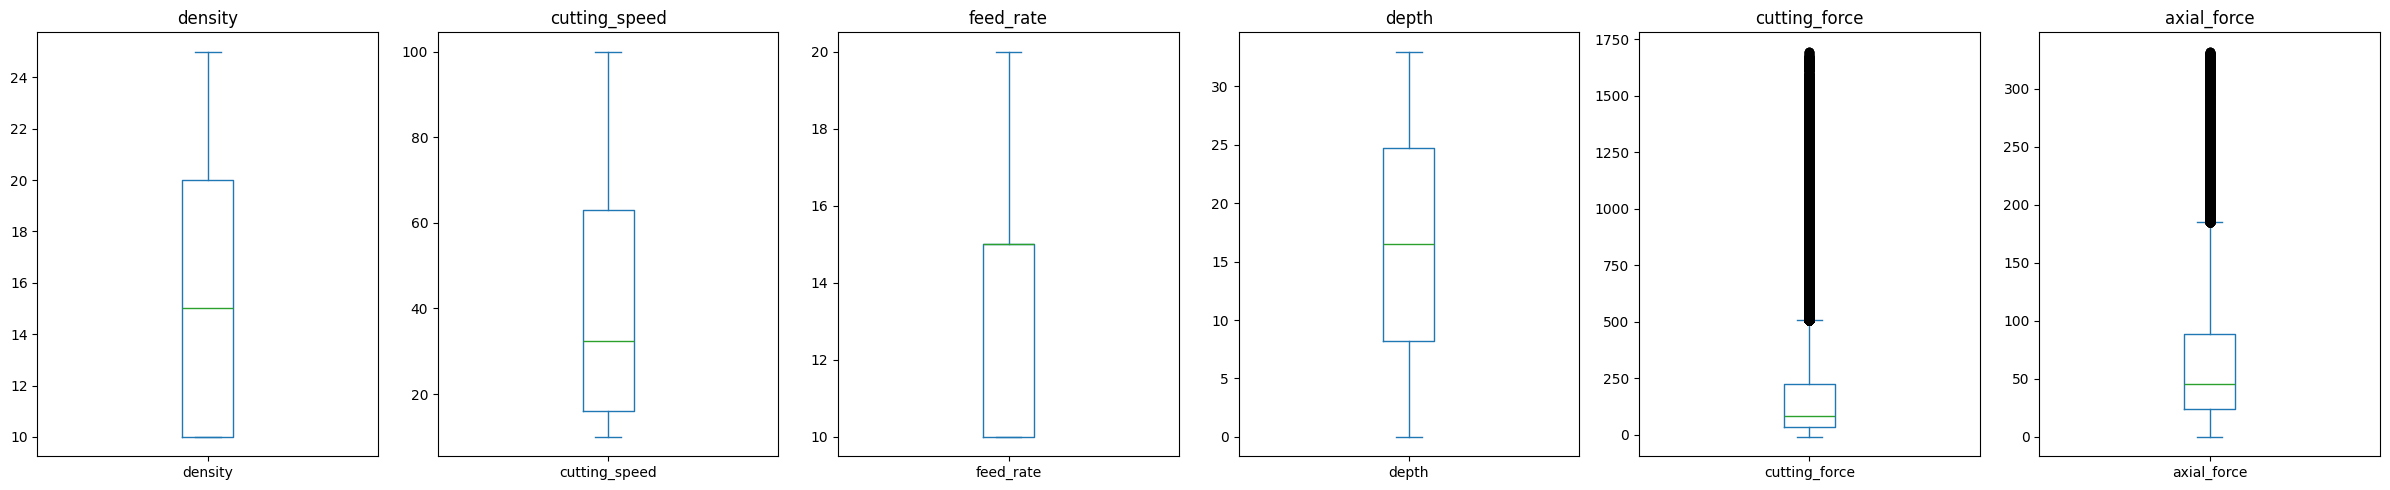

In [9]:
fig, axes = plt.subplots(1, len(num_cols), figsize=(4 * len(num_cols), 5))
if len(num_cols) == 1:
    axes = [axes]
for ax, col in zip(axes, num_cols):
    df[col].plot(kind="box", ax=ax, title=col)
plt.tight_layout()
plt.show()

### Correlation Heatmap

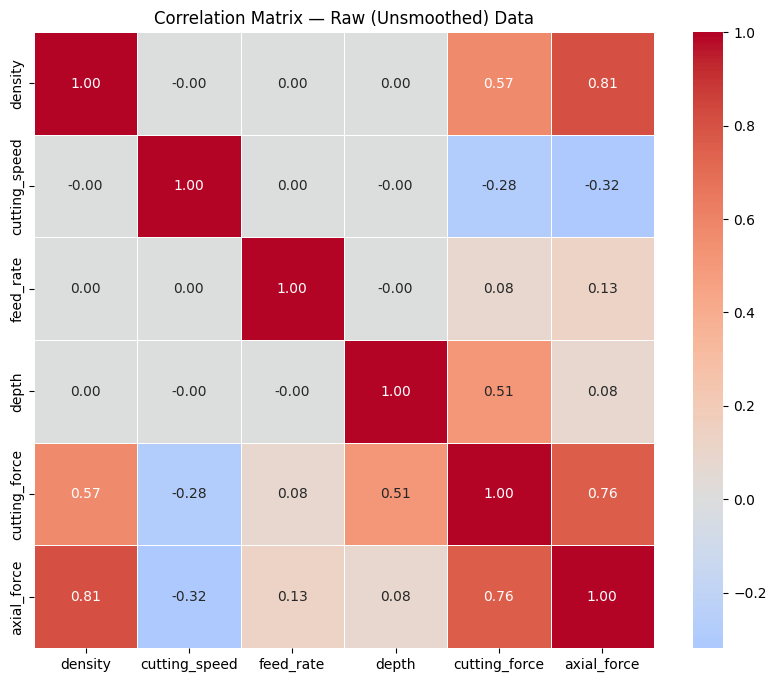

In [10]:
if len(num_cols) > 1:
    plt.figure(figsize=(10, 8))
    sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f",
                cmap="coolwarm", center=0, linewidths=0.5)
    plt.title("Correlation Matrix — Raw (Unsmoothed) Data")
    plt.show()

### Physically Implausible Values

In [11]:
force_cols = ['axial_force', 'cutting_force']
for col in force_cols:
    n_neg = (df[col] < 0).sum()
    print(f"{col}: {n_neg} negative values ({n_neg / len(df) * 100:.3f}%), min = {df[col].min():.3f}")

neg_depth = df.loc[df['cutting_force'] < 0, 'depth']
print("\nDepth distribution where cutting_force < 0 (checking if this is start-of-cut noise):")
print(neg_depth.describe())

axial_force: 0 negative values (0.000%), min = 0.000
cutting_force: 514 negative values (0.182%), min = -9.766

Depth distribution where cutting_force < 0 (checking if this is start-of-cut noise):
count    514.00000
mean       0.35106
std        0.42760
min        0.01700
25%        0.06700
50%        0.16700
75%        0.46700
max        2.91700
Name: depth, dtype: float64


## Parameters Distribution for Each Insertion

### Parameters

In [12]:
params = ['density', 'cutting_speed', 'feed_rate']

df['experiment_id'] = df.groupby(params)['depth'].transform(
    lambda x: (x == 0).cumsum()
)

### Summary Table

In [13]:
summary = (df.groupby(params)['experiment_id']
             .max()
             .reset_index(name='experiment_count')
             .sort_values('experiment_count', ascending=False))

print(f"Total unique combinations: {len(summary)}")
print(f"Experiment count range: {summary['experiment_count'].min()} – {summary['experiment_count'].max()}")
print("\n── Experiments per combination ──")
display(summary)

Total unique combinations: 72
Experiment count range: 2 – 3

── Experiments per combination ──


,density,cutting_speed,feed_rate,experiment_count
0,10,10,10,3
1,10,10,15,3
2,10,10,20,3
3,10,16,10,3
4,10,16,15,3
...,...,...,...,...
67,25,63,15,2
68,25,63,20,2
69,25,100,10,2
70,25,100,15,2


### Total Experiment Conducted

In [14]:
total_experiments = summary['experiment_count'].sum()
print(f"Total experiments across all combinations: {total_experiments}")

Total experiments across all combinations: 198


### Design Grid Completeness

In [15]:
density_vals = sorted(df['density'].unique())
speed_vals = sorted(df['cutting_speed'].unique())
feed_vals = sorted(df['feed_rate'].unique())
expected_grid = len(density_vals) * len(speed_vals) * len(feed_vals)

print(f"density values ({len(density_vals)}): {density_vals}")
print(f"cutting_speed values ({len(speed_vals)}): {speed_vals}")
print(f"feed_rate values ({len(feed_vals)}): {feed_vals}")
print(f"\nExpected full-factorial combinations: {expected_grid}")
print(f"Observed combinations: {len(summary)}")

full_grid = pd.MultiIndex.from_product([density_vals, speed_vals, feed_vals], names=params).to_frame(index=False)
missing_combos = full_grid.merge(summary[params], on=params, how='left', indicator=True) \
    .query('_merge == "left_only"').drop(columns='_merge')
print(f"Missing combinations: {len(missing_combos)}")
if len(missing_combos):
    display(missing_combos)

density values (4): [np.int64(10), np.int64(15), np.int64(20), np.int64(25)]
cutting_speed values (6): [np.int64(10), np.int64(16), np.int64(25), np.int64(40), np.int64(63), np.int64(100)]
feed_rate values (3): [np.int64(10), np.int64(15), np.int64(20)]

Expected full-factorial combinations: 72
Observed combinations: 72
Missing combinations: 0


### Depth Monotonicity Check

In [16]:
depth_diff = df.groupby(params + ['experiment_id'])['depth'].diff()
n_decreasing = int((depth_diff < 0).sum())
n_flat = int((depth_diff == 0).sum())
print(f"Depth steps that decrease within an experiment: {n_decreasing}")
print(f"Depth steps that stay flat within an experiment: {n_flat}")

starts = df.groupby(params + ['experiment_id'])['depth'].first()
print(f"Experiments not starting at depth 0: {(starts != 0).sum()} / {len(starts)}")

Depth steps that decrease within an experiment: 0
Depth steps that stay flat within an experiment: 0
Experiments not starting at depth 0: 0 / 198


### Experiment Length Distribution

count     198.000000
mean     1430.000000
std       412.625615
min       990.000000
25%       990.000000
50%      1320.000000
75%      1980.000000
max      1980.000000
dtype: float64


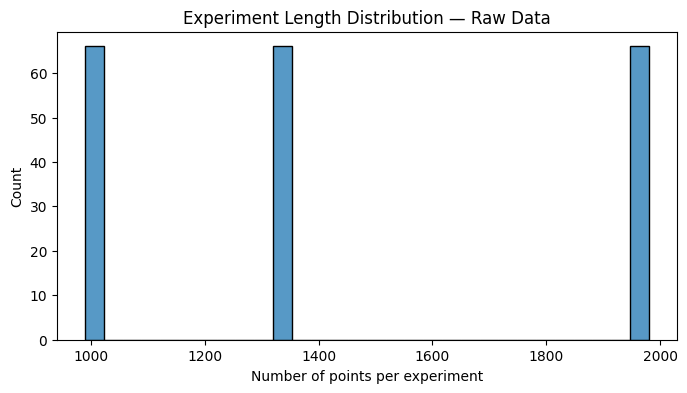

In [17]:
exp_lengths = (
    df.groupby(['density','cutting_speed','feed_rate','experiment_id'])
    .size()
)

print(exp_lengths.describe())

plt.figure(figsize=(8,4))
sns.histplot(exp_lengths, bins=30)
plt.xlabel("Number of points per experiment")
plt.ylabel("Count")
plt.title("Experiment Length Distribution — Raw Data")
plt.show()

## Raw Signal Noise Characterization

In [18]:
noise_stats = df.groupby(params + ['experiment_id']).apply(
    lambda g: pd.Series({
        'axial_step_std': g['axial_force'].diff().std(),
        'cutting_step_std': g['cutting_force'].diff().std(),
        'mean_cutting_force': g['cutting_force'].mean(),
    }),
    include_groups=False,
).reset_index()

print("Per-experiment step-to-step noise (std of first differences), raw signal:")
print(noise_stats[['axial_step_std', 'cutting_step_std']].describe())

Per-experiment step-to-step noise (std of first differences), raw signal:
       axial_step_std  cutting_step_std
count      198.000000        198.000000
mean         0.821607          5.256632
std          0.205246          1.478344
min          0.450651          3.002371
25%          0.627769          3.853919
50%          0.824187          4.988935
75%          0.960209          6.452997
max          1.363834          9.295952


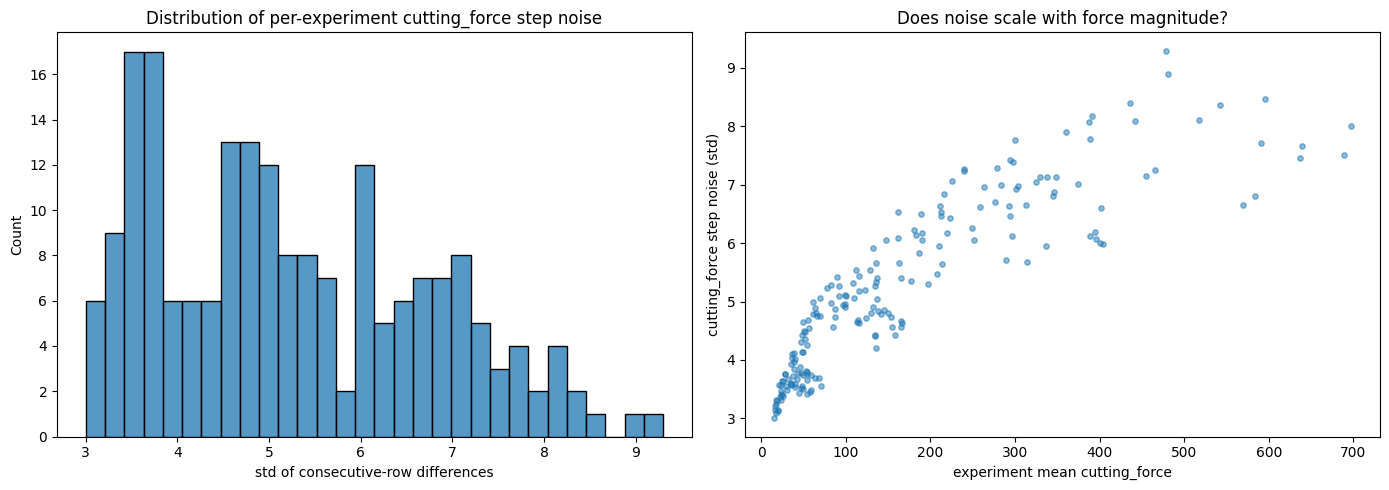

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(noise_stats['cutting_step_std'], bins=30, ax=axes[0])
axes[0].set_title("Distribution of per-experiment cutting_force step noise")
axes[0].set_xlabel("std of consecutive-row differences")

axes[1].scatter(noise_stats['mean_cutting_force'], noise_stats['cutting_step_std'], alpha=0.5, s=15)
axes[1].set_xlabel("experiment mean cutting_force")
axes[1].set_ylabel("cutting_force step noise (std)")
axes[1].set_title("Does noise scale with force magnitude?")
plt.tight_layout()
plt.show()

### Example Single-Experiment Trace

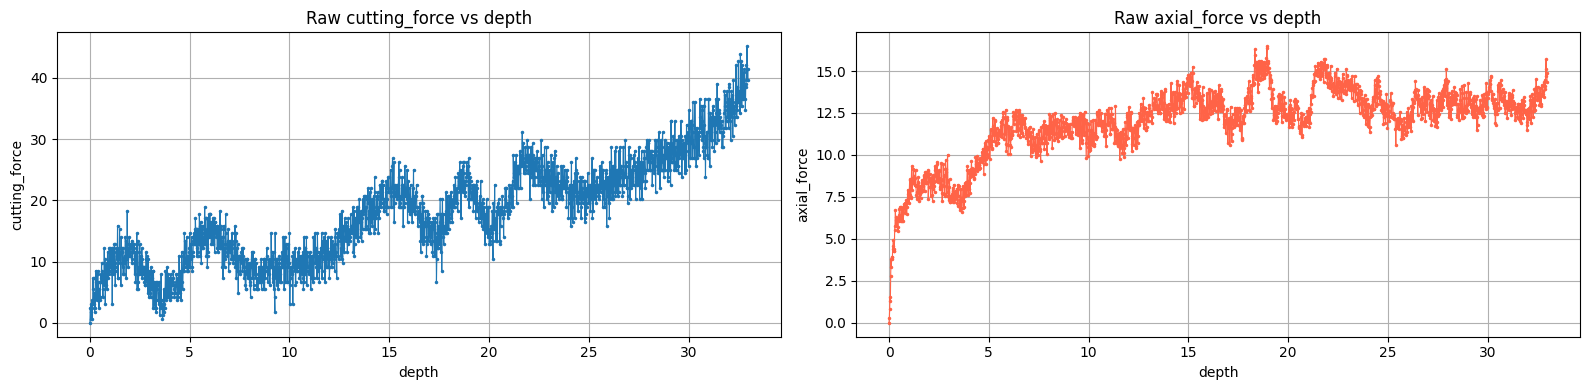

In [20]:
sample = df[
    (df['density'] == 10) &
    (df['cutting_speed'] == 100) &
    (df['feed_rate'] == 10)
]
exp = sample[sample['experiment_id'] == 1]

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
axes[0].plot(exp['depth'], exp['cutting_force'], marker='.', markersize=3, linewidth=0.8)
axes[0].set_xlabel('depth'); axes[0].set_ylabel('cutting_force')
axes[0].set_title('Raw cutting_force vs depth')
axes[0].grid()

axes[1].plot(exp['depth'], exp['axial_force'], marker='.', markersize=3, linewidth=0.8, color='tomato')
axes[1].set_xlabel('depth'); axes[1].set_ylabel('axial_force')
axes[1].set_title('Raw axial_force vs depth')
axes[1].grid()
plt.tight_layout()
plt.show()

## Replicate Variation (Irreducible Error) Audit

In [21]:
exp_summary = df.groupby(params + ['experiment_id']).agg(
    n_points=('depth', 'size'),
    max_depth=('depth', 'max'),
    mean_axial_force=('axial_force', 'mean'),
    mean_cutting_force=('cutting_force', 'mean'),
    std_cutting_force=('cutting_force', 'std'),
).reset_index()

combo_stats = (
    exp_summary.groupby(params)['mean_cutting_force']
    .agg(['mean', 'std', 'count'])
    .reset_index()
    .rename(columns={'mean': 'combo_mean_cf', 'std': 'replicate_std_cf', 'count': 'n_replicates'})
)

overall_var = exp_summary['mean_cutting_force'].var()
between_combo_var = combo_stats['combo_mean_cf'].var()
within_combo_var = (combo_stats['replicate_std_cf'] ** 2).mean()

print(f"Overall variance of per-experiment mean cutting_force : {overall_var:.2f}")
print(f"Between-combination variance (explained by parameters): {between_combo_var:.2f}")
print(f"Average within-combination (replicate) variance        : {within_combo_var:.2f}")
print(f"Replicate variance as % of overall variance             : {within_combo_var / overall_var * 100:.1f}%")

combo_stats_sorted = combo_stats.query('n_replicates >= 2').sort_values('replicate_std_cf', ascending=False)
print("\nCombinations with the largest replicate-to-replicate disagreement in mean cutting_force:")
display(combo_stats_sorted.head(10))

Overall variance of per-experiment mean cutting_force : 24605.57
Between-combination variance (explained by parameters): 28773.29
Average within-combination (replicate) variance        : 35.66
Replicate variance as % of overall variance             : 0.1%

Combinations with the largest replicate-to-replicate disagreement in mean cutting_force:


,density,cutting_speed,feed_rate,combo_mean_cf,replicate_std_cf,n_replicates
36,20,10,10,313.179019,23.794030,3
58,25,16,15,530.176655,17.302261,2
64,25,40,15,352.398986,11.173880,2
69,25,100,10,146.077937,10.864992,2
43,20,25,15,266.941979,10.662392,3
60,25,25,10,381.215882,9.927574,2
54,25,10,10,576.559823,9.771196,2
40,20,16,15,322.398087,8.631369,3
70,25,100,15,171.204537,8.345440,2
47,20,40,20,234.814719,8.319242,3


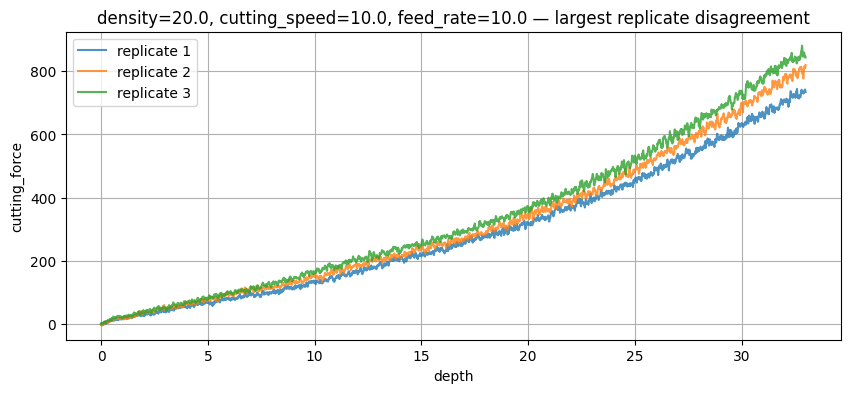

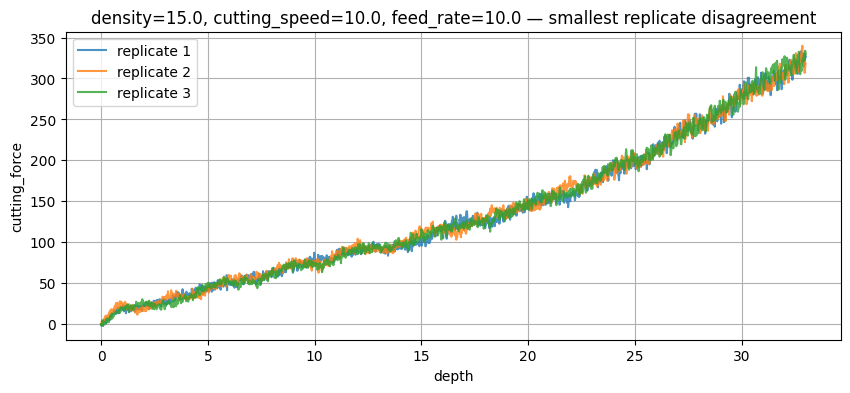

In [22]:
def plot_replicates(density, cutting_speed, feed_rate, title_suffix=""):
    subset = df[(df.density == density) & (df.cutting_speed == cutting_speed) & (df.feed_rate == feed_rate)]
    plt.figure(figsize=(10, 4))
    for exp_id, g in subset.groupby('experiment_id'):
        plt.plot(g['depth'], g['cutting_force'], label=f"replicate {exp_id}", alpha=0.8)
    plt.xlabel("depth")
    plt.ylabel("cutting_force")
    plt.title(f"density={density}, cutting_speed={cutting_speed}, feed_rate={feed_rate} {title_suffix}")
    plt.legend()
    plt.grid()
    plt.show()

worst = combo_stats_sorted.iloc[0]
plot_replicates(worst['density'], worst['cutting_speed'], worst['feed_rate'], "— largest replicate disagreement")

best = combo_stats_sorted.iloc[-1]
plot_replicates(best['density'], best['cutting_speed'], best['feed_rate'], "— smallest replicate disagreement")

## Cross-Condition Comparison

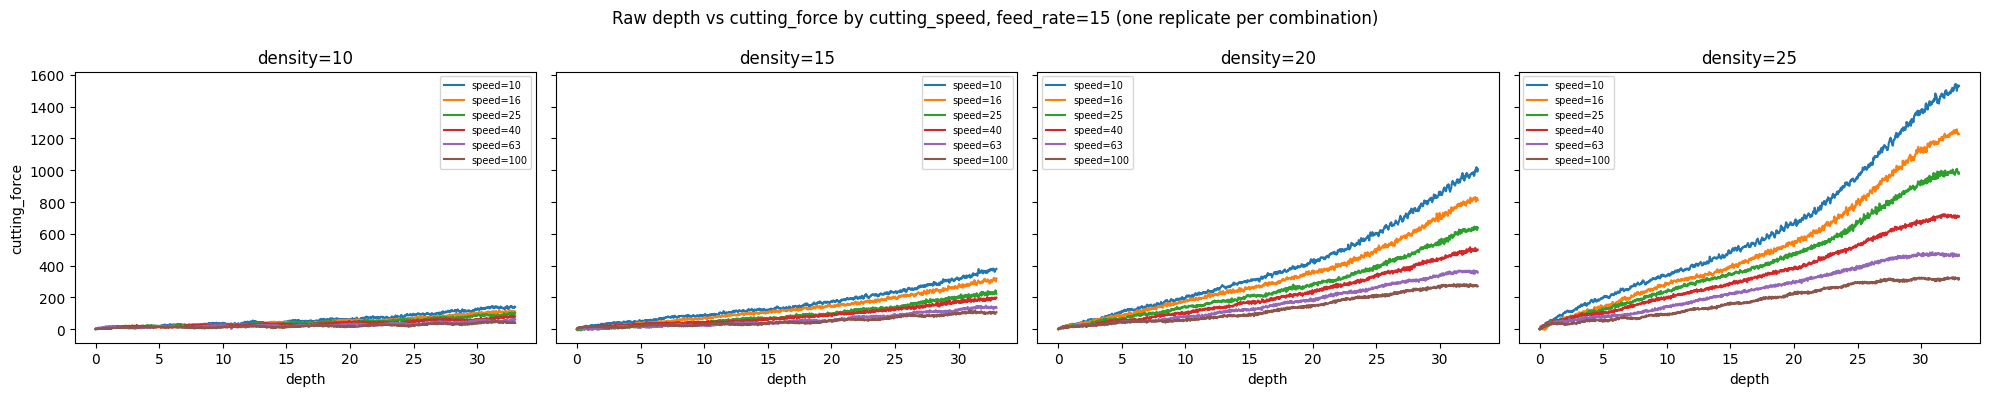

In [23]:
feed_rate_fixed = sorted(df['feed_rate'].unique())[len(df['feed_rate'].unique()) // 2]
density_vals = sorted(df['density'].unique())

fig, axes = plt.subplots(1, len(density_vals), figsize=(5 * len(density_vals), 4), sharey=True)
for ax, density in zip(axes, density_vals):
    subset = df[(df.density == density) & (df.feed_rate == feed_rate_fixed)]
    for speed, g in subset.groupby('cutting_speed'):
        first_exp = g[g.experiment_id == g.experiment_id.min()]
        ax.plot(first_exp['depth'], first_exp['cutting_force'], label=f"speed={speed}")
    ax.set_title(f"density={density}")
    ax.set_xlabel("depth")
    ax.legend(fontsize=7)
axes[0].set_ylabel("cutting_force")
plt.suptitle(f"Raw depth vs cutting_force by cutting_speed, feed_rate={feed_rate_fixed} (one replicate per combination)")
plt.tight_layout()
plt.show()

## Per-Experiment Aggregated Correlation

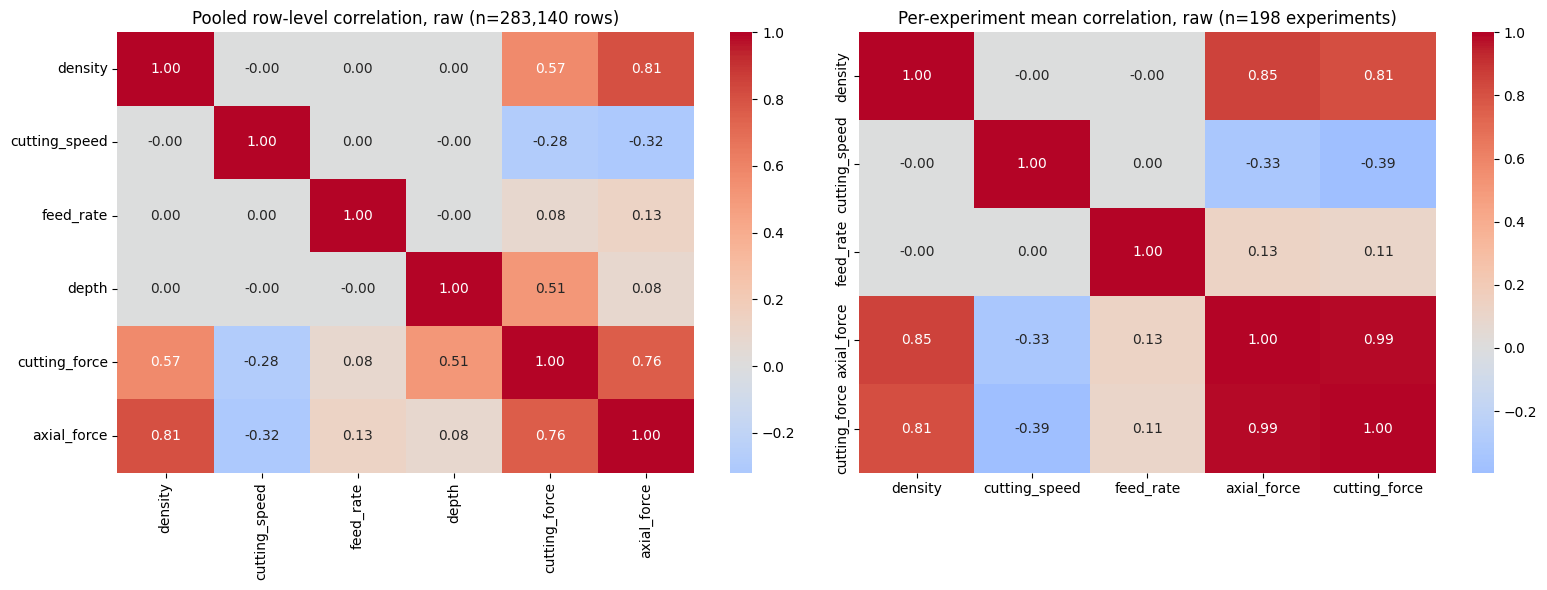

In [24]:
exp_level = exp_summary.rename(
    columns={'mean_axial_force': 'axial_force', 'mean_cutting_force': 'cutting_force'}
)[['density', 'cutting_speed', 'feed_rate', 'axial_force', 'cutting_force']]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[0])
axes[0].set_title(f"Pooled row-level correlation, raw (n={len(df):,} rows)")

sns.heatmap(exp_level.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[1])
axes[1].set_title(f"Per-experiment mean correlation, raw (n={len(exp_level)} experiments)")
plt.tight_layout()
plt.show()